In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, DataStructs
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('nr_ic_merged.csv')

In [3]:
# Keep only valid SMILES
def smiles_to_mol(s):
    if pd.isna(s) or str(s).lower() == 'nan':
        return None
    try:
        return Chem.MolFromSmiles(str(s))
    except Exception:
        return None

df['mol'] = df['Smiles'].map(smiles_to_mol)
df = df[df['mol'].notna()].copy()

In [4]:
df

,Unnamed: 0,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Value,Standard Units,pChEMBL Value,Target,mol
0,0,CHEMBL390728,NaN,CCC1CCNc2cc3[nH]c(=O)cc(C(F)(F)F)c3cc21,IC50,4580.0,nM,5.34,ar,<rdkit.Chem.rdchem.Mol object at 0x7fb318763ed0>
1,1,CHEMBL3936931,NaN,O=C(N[C@H]1CC[C@H](Oc2ccnc3c(Br)cccc23)CC1)c1c...,IC50,190.0,nM,6.72,ar,<rdkit.Chem.rdchem.Mol object at 0x7fb318763f40>
2,2,CHEMBL418684,NaN,CC1=CC(C)(C)Nc2ccc3c(c21)COc1c(F)cc(F)cc1-3,IC50,644.0,nM,6.19,ar,<rdkit.Chem.rdchem.Mol object at 0x7fb318784040>
3,3,CHEMBL235126,NaN,O=c1cc(O)c2cc(N(CC(F)(F)F)CC(F)(F)F)ccc2[nH]1,IC50,7.0,nM,8.15,ar,<rdkit.Chem.rdchem.Mol object at 0x7fb3187840b0>
4,4,CHEMBL266491,NaN,COCCOc1ccccc1-c1ccc(C#N)c(C(F)(F)F)c1,IC50,2230.0,nM,5.65,ar,<rdkit.Chem.rdchem.Mol object at 0x7fb318784120>
...,...,...,...,...,...,...,...,...,...,...
14168,14168,CHEMBL118963,NaN,O=C1Nc2ccc(-c3cccc(Cl)c3)cc2C12CCCC2,IC50,32.0,nM,7.50,pr,<rdkit.Chem.rdchem.Mol object at 0x7fb31820a730>
14169,14169,CHEMBL117461,NaN,N#Cc1cc(F)cc(-c2ccc3c(c2)C2(CCCC2)C(=O)N3)c1,IC50,13.2,nM,7.88,pr,<rdkit.Chem.rdchem.Mol object at 0x7fb31820a7a0>
14170,14170,CHEMBL117322,NaN,CC1C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,30.6,nM,7.51,pr,<rdkit.Chem.rdchem.Mol object at 0x7fb31820a810>
14171,14171,CHEMBL119058,NaN,CC1(C)C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,102.0,nM,6.99,pr,<rdkit.Chem.rdchem.Mol object at 0x7fb31820a880>


In [5]:
FPSIZE = 4096
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=FPSIZE)


def mol_to_fp(mol):
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((FPSIZE,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


df['fp'] = df['mol'].map(mol_to_fp)

In [6]:
df

,Unnamed: 0,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Value,Standard Units,pChEMBL Value,Target,mol,fp
0,0,CHEMBL390728,NaN,CCC1CCNc2cc3[nH]c(=O)cc(C(F)(F)F)c3cc21,IC50,4580.0,nM,5.34,ar,<rdkit.Chem.rdchem.Mol object at 0x7fb318763ed0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1,CHEMBL3936931,NaN,O=C(N[C@H]1CC[C@H](Oc2ccnc3c(Br)cccc23)CC1)c1c...,IC50,190.0,nM,6.72,ar,<rdkit.Chem.rdchem.Mol object at 0x7fb318763f40>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,2,CHEMBL418684,NaN,CC1=CC(C)(C)Nc2ccc3c(c21)COc1c(F)cc(F)cc1-3,IC50,644.0,nM,6.19,ar,<rdkit.Chem.rdchem.Mol object at 0x7fb318784040>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,3,CHEMBL235126,NaN,O=c1cc(O)c2cc(N(CC(F)(F)F)CC(F)(F)F)ccc2[nH]1,IC50,7.0,nM,8.15,ar,<rdkit.Chem.rdchem.Mol object at 0x7fb3187840b0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,4,CHEMBL266491,NaN,COCCOc1ccccc1-c1ccc(C#N)c(C(F)(F)F)c1,IC50,2230.0,nM,5.65,ar,<rdkit.Chem.rdchem.Mol object at 0x7fb318784120>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
...,...,...,...,...,...,...,...,...,...,...,...
14168,14168,CHEMBL118963,NaN,O=C1Nc2ccc(-c3cccc(Cl)c3)cc2C12CCCC2,IC50,32.0,nM,7.50,pr,<rdkit.Chem.rdchem.Mol object at 0x7fb31820a730>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
14169,14169,CHEMBL117461,NaN,N#Cc1cc(F)cc(-c2ccc3c(c2)C2(CCCC2)C(=O)N3)c1,IC50,13.2,nM,7.88,pr,<rdkit.Chem.rdchem.Mol object at 0x7fb31820a7a0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
14170,14170,CHEMBL117322,NaN,CC1C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,30.6,nM,7.51,pr,<rdkit.Chem.rdchem.Mol object at 0x7fb31820a810>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
14171,14171,CHEMBL119058,NaN,CC1(C)C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,102.0,nM,6.99,pr,<rdkit.Chem.rdchem.Mol object at 0x7fb31820a880>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [7]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
target_encoded = encoder.fit_transform(df[['Target']])
target_names = encoder.categories_[0]

# Store each one-hot vector as a list
df['target_encoded'] = target_encoded.tolist()

In [8]:
df

,Unnamed: 0,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Value,Standard Units,pChEMBL Value,Target,mol,fp,target_encoded
0,0,CHEMBL390728,NaN,CCC1CCNc2cc3[nH]c(=O)cc(C(F)(F)F)c3cc21,IC50,4580.0,nM,5.34,ar,<rdkit.Chem.rdchem.Mol object at 0x7fb318763ed0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
1,1,CHEMBL3936931,NaN,O=C(N[C@H]1CC[C@H](Oc2ccnc3c(Br)cccc23)CC1)c1c...,IC50,190.0,nM,6.72,ar,<rdkit.Chem.rdchem.Mol object at 0x7fb318763f40>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
2,2,CHEMBL418684,NaN,CC1=CC(C)(C)Nc2ccc3c(c21)COc1c(F)cc(F)cc1-3,IC50,644.0,nM,6.19,ar,<rdkit.Chem.rdchem.Mol object at 0x7fb318784040>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
3,3,CHEMBL235126,NaN,O=c1cc(O)c2cc(N(CC(F)(F)F)CC(F)(F)F)ccc2[nH]1,IC50,7.0,nM,8.15,ar,<rdkit.Chem.rdchem.Mol object at 0x7fb3187840b0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
4,4,CHEMBL266491,NaN,COCCOc1ccccc1-c1ccc(C#N)c(C(F)(F)F)c1,IC50,2230.0,nM,5.65,ar,<rdkit.Chem.rdchem.Mol object at 0x7fb318784120>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...
14168,14168,CHEMBL118963,NaN,O=C1Nc2ccc(-c3cccc(Cl)c3)cc2C12CCCC2,IC50,32.0,nM,7.50,pr,<rdkit.Chem.rdchem.Mol object at 0x7fb31820a730>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
14169,14169,CHEMBL117461,NaN,N#Cc1cc(F)cc(-c2ccc3c(c2)C2(CCCC2)C(=O)N3)c1,IC50,13.2,nM,7.88,pr,<rdkit.Chem.rdchem.Mol object at 0x7fb31820a7a0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
14170,14170,CHEMBL117322,NaN,CC1C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,30.6,nM,7.51,pr,<rdkit.Chem.rdchem.Mol object at 0x7fb31820a810>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
14171,14171,CHEMBL119058,NaN,CC1(C)C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,102.0,nM,6.99,pr,<rdkit.Chem.rdchem.Mol object at 0x7fb31820a880>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"


In [9]:
import numpy as np

# Convert fp arrays to tuples so they are hashable
df['fp_tuple'] = df['fp'].apply(lambda x: tuple(x))

# Group by fingerprint and OR-combine their one-hot target vectors
grouped = df.groupby('fp_tuple')['target_encoded'].apply(
    lambda rows: np.any(np.vstack(rows.values), axis=0).astype(int)
)

df_agg = grouped.reset_index()

# Convert fp back to numpy array
df_agg['fp'] = df_agg['fp_tuple'].apply(lambda x: np.array(x))

# Rename the aggregated target vector
df_agg = df_agg.rename(columns={'target_encoded': 'target'})

# Remove helper column
df_agg = df_agg.drop(columns=['fp_tuple'])

In [10]:
df_agg

,target,fp
0,"[0, 1, 1, 1, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"[0, 1, 1, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,"[0, 1, 1, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,"[0, 1, 1, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,"[1, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...
7202,"[0, 0, 0, 0, 0, 1]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7203,"[0, 0, 0, 0, 0, 1]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7204,"[0, 0, 0, 0, 0, 1]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7205,"[0, 0, 0, 0, 0, 1]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [11]:
x = np.vstack(df_agg['fp'].values)
y = np.vstack(df_agg['target'].values)

In [12]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

In [13]:
model = OneVsRestClassifier(
        RandomForestClassifier(
            n_estimators=40,
            max_depth=None,
            random_state=42,
            n_jobs=-1
))
model.fit(x_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,n_jobs,None
,verbose,0
,n_estimators,40
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None


In [14]:
import numpy as np

# Predict probabilities
y_pred_prob = model.predict_proba(x_test)

# Stack into a matrix: shape (n_samples, n_labels)
y_pred_prob_matrix = np.column_stack(y_pred_prob)
y_pred_prob_matrix = y_pred_prob_matrix.T

from sklearn.metrics import roc_auc_score

# ROC-AUC per target
roc_auc_per_target = [
    roc_auc_score(y_test[:, i], y_pred_prob_matrix[:, i])
    for i in range(y_test.shape[1])
]

print("ROC-AUC per target:", roc_auc_per_target)
print("Mean ROC-AUC:", np.mean(roc_auc_per_target))


ROC-AUC per target: [0.9711836813733659, 0.982656167195658, 0.9761559691828754, 0.9913664834620718, 0.981223646256238, 0.9619222093914245]
Mean ROC-AUC: 0.9774180261436056


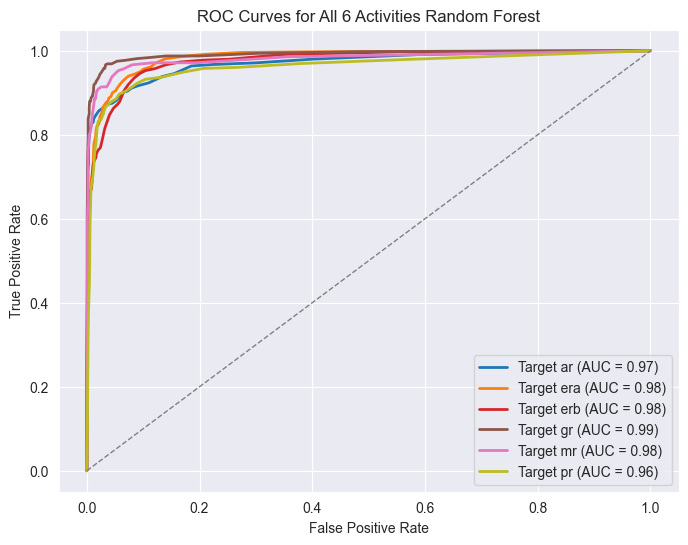

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np
import matplotlib

n_targets = y_test.shape[1]
cmap = matplotlib.colormaps.get_cmap('tab10')

plt.figure(figsize=(8, 6))

for i in range(n_targets):
    fpr, tpr, thresholds = roc_curve(y_test[:, i], y_pred_prob_matrix[:, i])
    auc_score = roc_auc_score(y_test[:, i], y_pred_prob_matrix[:, i])
    color = cmap(i / n_targets)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"Target {target_names[i]} (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All 6 Activities Random Forest")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
